# Optimization Algorithms for Deep Learning

**Domain:** `deep-learning`
**Level:** Intermediate
**Prerequisites:** basic Python, basic linear algebra (dot products, matrices), basic calculus (gradients, partial derivatives)

## Intro: rolling a ball down a narrow ravine

Imagine you're standing at the top of a canyon shaped like a long, narrow
valley — steep walls on either side, but the floor of the valley slopes only
very gently toward the exit. You drop a ball and watch it roll. What happens?

The ball doesn't roll smoothly toward the exit. It shoots down one steep wall,
overshoots the valley floor, climbs partway up the *other* wall, rolls back
down, overshoots again... It zig-zags back and forth across the narrow
direction, and only *creeps* forward along the gentle direction, one small
net step at a time. If the canyon is long enough, the ball can bounce for a
very long time before it ever reaches the exit.

This is exactly what happens to **plain gradient descent** when the loss
surface of a neural network is shaped like that canyon (which it almost
always is, in some direction, for real networks). The previous tutorial in
this series (`perceptron-and-backpropagation`) derived the gradient descent
update rule and used it successfully — but on a small, well-behaved problem.
Real loss surfaces are typically **ill-conditioned**: much steeper in some
directions than others. A learning rate small enough to avoid blowing up in
the steep direction is *painfully* slow in the gentle direction.

**Optimizers** are algorithms that decide, at every training step, exactly
how far and in what direction to move the weights — using more information
than "just follow today's gradient." By the end of this tutorial you will be
able to:

- Explain why plain SGD oscillates and crawls on ill-conditioned loss
  surfaces, using the ravine picture above.
- Derive, from scratch, the update rules for SGD with **momentum**,
  **RMSprop**, and **Adam** — and state exactly what new problem each one
  solves.
- Implement all four optimizers in numpy and *watch* their trajectories
  differ on the same 2D loss surface.
- Train an identical real PyTorch model on real MNIST with all four
  optimizers via `torch.optim`, and see the practical difference in training
  curves and final test accuracy — not just the toy 2D case.
- Know which optimizer to reach for by default, and when the "boring" choice
  (SGD + momentum) is still the right one.


## The idea, intuitively

Let's see the ravine problem before touching any equations. Below is a tiny,
elongated bowl-shaped loss surface — steep in one direction, shallow in the
other, exactly like the canyon. We drop a point on it and take plain gradient
descent steps.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

# A tiny elongated ("ravine") loss surface: steep in y, gentle in x.
def toy_loss(theta):
    x, y = theta
    return 0.05 * x**2 + 5.0 * y**2

def toy_grad(theta):
    x, y = theta
    return np.array([0.1 * x, 10.0 * y])

theta = np.array([4.0, 3.5])   # starting point
lr = 0.18
path = [theta.copy()]
for step in range(25):
    theta = theta - lr * toy_grad(theta)
    path.append(theta.copy())
path = np.array(path)

print("Start:", path[0], " -> after 25 plain-SGD steps:", np.round(path[-1], 3))
print("Notice how little progress x made compared to how much y oscillated.")


Start: [4.  3.5]  -> after 25 plain-SGD steps: [ 2.54  -0.013]
Notice how little progress x made compared to how much y oscillated.


Run that and look at the printed path: `y` (the steep direction) has
already overshot past zero and is bouncing sign to sign, while `x` (the
gentle direction) has barely moved from 4.0. That's the ravine, in numbers.
We'll plot this properly as a contour map in the Visuals section — but the
takeaway already shows up in plain print statements:

> **Takeaway:** the *same* learning rate is simultaneously too big (causing
> zig-zag overshoot) in steep directions and too small (causing crawling) in
> shallow directions. A smarter optimizer needs to treat directions
> differently, and needs to remember something about *past* gradients, not
> just react to the current one.

That's exactly what the three optimizers below add, one idea at a time:

- **Momentum** — keep a running "velocity" that accumulates gradients over
  time, so consistent directions build up speed and oscillating directions
  cancel out.
- **RMSprop** — track a per-parameter running average of *squared* gradients,
  and divide the step by it, so steep directions automatically get smaller
  steps and shallow directions get relatively larger ones.
- **Adam** — combine both ideas (a velocity term *and* a per-parameter
  adaptive step size) plus a bias-correction fix for the first few steps.


## Going deeper: the formal definition

Let $\theta_t$ denote the parameter vector at step $t$, $\mathcal{L}(\theta)$
the loss, and $g_t = \nabla_\theta \mathcal{L}(\theta_t)$ the gradient
evaluated at $\theta_t$ (for a mini-batch, this is the batch's average
gradient). $\eta$ is the learning rate.

### Vanilla SGD

$$
\theta_{t+1} = \theta_t - \eta\, g_t
$$

Every step reacts only to the *current* gradient. It has no memory, and it
uses the exact same step size $\eta$ in every direction — which is precisely
why it struggles on the ravine above: the loss's curvature is direction
(and, in general, parameter) -dependent, but $\eta$ is not.

### SGD with momentum

Momentum keeps a **velocity** $v_t$: an exponentially-weighted moving average
of past gradients, and steps in the velocity's direction instead of the raw
gradient's:

$$
v_t = \beta\, v_{t-1} + g_t, \qquad \theta_{t+1} = \theta_t - \eta\, v_t
$$

with $v_0 = 0$ and a momentum coefficient $\beta \in [0, 1)$ (commonly
$0.9$). Unrolling the recursion, $v_t = \sum_{k=0}^{t} \beta^{t-k} g_k$ — a
weighted sum of *all* past gradients, with exponentially decaying weight on
older ones.

**Why this fixes the ravine:** in the oscillating (steep) direction,
consecutive gradients keep flipping sign, so they partially *cancel* in the
running sum $v_t$ — the oscillation is damped. In the consistent (shallow)
direction, gradients keep the same sign step after step, so they *add up* in
$v_t$ — the effective step size in that direction grows well past $\eta$
alone. Momentum is literally the physical analogy: a ball with mass resists
sudden direction changes and keeps rolling where it's already been rolling.

### RMSprop

RMSprop (Tieleman & Hinton, 2012) takes the opposite approach: instead of
smoothing the gradient direction, it rescales *each parameter's* step size by
how large that parameter's gradients have recently been. It tracks a running
average of **squared** gradients, elementwise:

$$
s_t = \beta_2\, s_{t-1} + (1 - \beta_2)\, g_t^2, \qquad
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{s_t} + \epsilon}\, g_t
$$

with $s_0 = 0$, $\beta_2$ commonly $0.9$–$0.999$, and a tiny $\epsilon$
(e.g. $10^{-8}$) purely to avoid dividing by zero. All operations are
elementwise (per-parameter) — every entry of $\theta$ gets its own effective
learning rate $\eta / (\sqrt{s_t}+\epsilon)$.

**Why this fixes the ravine:** in the steep direction, gradients are
consistently large in magnitude, so $s_t$ grows large there and the *step is
shrunk* precisely where the surface is steep. In the shallow direction,
gradients are consistently small, $s_t$ stays small, and the step stays
close to full size. The two directions end up taking comparably-sized steps
instead of one dominating the other — the optimizer automatically
re-conditions the problem per parameter.

### Adam

Adam (Kingma & Ba, 2015 — "Adaptive Moment Estimation") combines both ideas:
a momentum-style running average of the gradient (the **first moment**, i.e.
mean) and an RMSprop-style running average of the squared gradient (the
**second moment**, i.e. uncentered variance) — plus a **bias correction**
term:

$$
m_t = \beta_1\, m_{t-1} + (1-\beta_1)\, g_t, \qquad
v_t = \beta_2\, v_{t-1} + (1-\beta_2)\, g_t^2
$$

with $m_0 = v_0 = 0$ and typically $\beta_1 = 0.9$, $\beta_2 = 0.999$.
Because both moving averages start at zero, they are systematically biased
toward zero for the first several steps (most obviously at $t=1$: $m_1 =
(1-\beta_1) g_1$, far smaller in magnitude than $g_1$ itself). Adam corrects
for this directly:

$$
\hat{m}_t = \frac{m_t}{1 - \beta_1^t}, \qquad
\hat{v}_t = \frac{v_t}{1 - \beta_2^t}
$$

*Sketch of why this correction is exactly right:* taking the expectation of
the $m_t$ recursion and assuming (as a simplifying approximation) that
$\mathbb{E}[g_k] \approx \mathbb{E}[g_t]$ for the recent past gives
$\mathbb{E}[m_t] \approx \mathbb{E}[g_t]\,(1-\beta_1^t)$ — dividing by exactly
$1-\beta_1^t$ removes that factor, so $\hat m_t$ is an (approximately)
unbiased estimate of the true mean gradient. The same argument applies to
$\hat v_t$ with $\beta_2$. As $t$ grows, $\beta_1^t, \beta_2^t \to 0$ and the
correction fades to $1$, so it matters only in early training.

Finally, the update combines both corrected moments exactly like RMSprop, but
using $\hat m_t$ (the smoothed gradient) in place of the raw gradient $g_t$:

$$
\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon}\, \hat{m}_t
$$

Adam therefore gets momentum's oscillation-damping *and* RMSprop's
per-parameter step-size adaptation in a single update rule, which is a large
part of why it became the default starting optimizer for deep learning.


## Visuals & implementation, part 1: watching all four optimizers on the same ravine

We now implement all four update rules from scratch in numpy and run each of
them, starting from the *same* point on the *same* elongated bowl used above,
so their trajectories are directly comparable. This is the single most
important visual in this tutorial: it turns four abstract update equations
into four visibly different paths across the same terrain.


In [2]:
def loss_surface(theta):
    '''Elongated quadratic bowl: steep in y (curvature 10), gentle in x
    (curvature 0.1) -- a 100x condition-number ravine, same shape used in
    "The idea, intuitively" above.'''
    x, y = theta
    return 0.05 * x**2 + 5.0 * y**2

def loss_grad(theta):
    x, y = theta
    return np.array([0.1 * x, 10.0 * y])

START = np.array([4.0, 3.5])
N_STEPS = 60


In [3]:
def run_sgd(lr, n_steps=N_STEPS):
    theta = START.copy()
    path = [theta.copy()]
    for _ in range(n_steps):
        theta = theta - lr * loss_grad(theta)
        path.append(theta.copy())
    return np.array(path)


def run_momentum(lr, beta=0.9, n_steps=N_STEPS):
    theta = START.copy()
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(n_steps):
        g = loss_grad(theta)
        v = beta * v + g
        theta = theta - lr * v
        path.append(theta.copy())
    return np.array(path)


def run_rmsprop(lr, beta2=0.9, eps=1e-8, n_steps=N_STEPS):
    theta = START.copy()
    s = np.zeros_like(theta)
    path = [theta.copy()]
    for _ in range(n_steps):
        g = loss_grad(theta)
        s = beta2 * s + (1 - beta2) * g**2
        theta = theta - lr * g / (np.sqrt(s) + eps)
        path.append(theta.copy())
    return np.array(path)


def run_adam(lr, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=N_STEPS):
    theta = START.copy()
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    path = [theta.copy()]
    for t in range(1, n_steps + 1):
        g = loss_grad(theta)
        m = beta1 * m + (1 - beta1) * g
        v = beta2 * v + (1 - beta2) * g**2
        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)
        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())
    return np.array(path)


# A shared learning rate small enough that plain SGD doesn't diverge in the
# steep direction (curvature 10 -> SGD is unstable above lr = 2/10 = 0.2).
LR = 0.18
paths = {
    "SGD":              run_sgd(LR),
    "SGD + momentum":   run_momentum(LR * 0.4),
    "RMSprop":          run_rmsprop(lr=0.5),
    "Adam":             run_adam(lr=0.5),
}
for name, p in paths.items():
    final_loss = loss_surface(p[-1])
    print(f"{name:16s} final theta = {np.round(p[-1], 4)}  final loss = {final_loss:.5f}")


SGD              final theta = [1.3451 0.    ]  final loss = 0.09046
SGD + momentum   final theta = [-0.1905 -0.0916]  final loss = 0.04373
RMSprop          final theta = [-0.      0.0002]  final loss = 0.00000
Adam             final theta = [0.0725 0.124 ]  final loss = 0.07719


A note on the learning rates above: each optimizer's effective step
size is scaled differently by its own update rule (momentum accumulates
velocity, RMSprop/Adam divide by a running gradient magnitude), so "the same
$\eta$" does not mean "the same effective step." We picked, for each
optimizer, a learning rate near the largest stable one on this surface — the
fair comparison practitioners actually care about is *"how fast does each
optimizer reach the minimum without diverging, at its own best-ish
setting,"* not *"what does identical $\eta$ do to all four."*


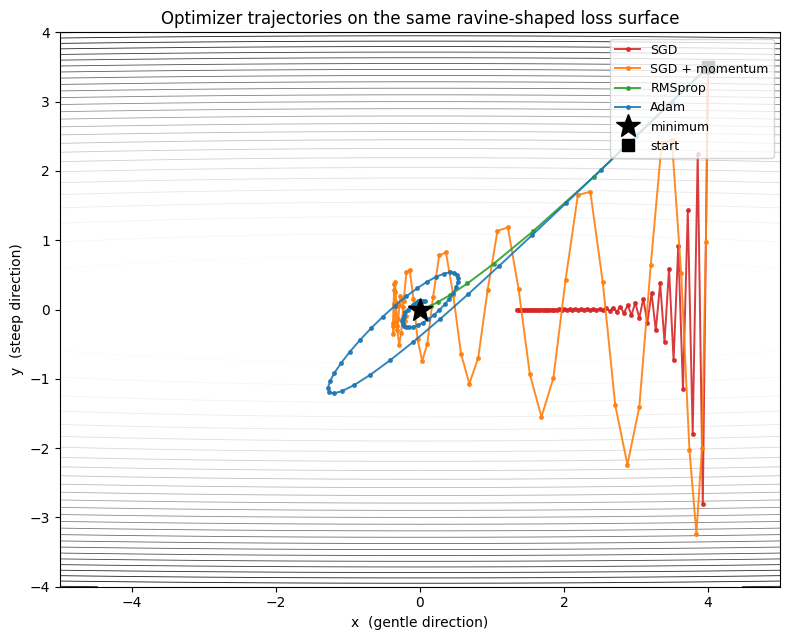

In [4]:
fig, ax = plt.subplots(figsize=(8, 6.5))

xx, yy = np.meshgrid(np.linspace(-5, 5, 300), np.linspace(-4, 4, 300))
zz = 0.05 * xx**2 + 5.0 * yy**2
ax.contour(xx, yy, zz, levels=30, cmap="Greys", linewidths=0.6)

colors = {"SGD": "#d62728", "SGD + momentum": "#ff7f0e", "RMSprop": "#2ca02c", "Adam": "#1f77b4"}
for name, p in paths.items():
    ax.plot(p[:, 0], p[:, 1], "-o", color=colors[name], markersize=2.5,
             linewidth=1.4, label=name, alpha=0.9)

ax.plot(0, 0, "k*", markersize=18, label="minimum", zorder=5)
ax.plot(START[0], START[1], "ks", markersize=8, label="start", zorder=5)
ax.set_xlabel("x  (gentle direction)")
ax.set_ylabel("y  (steep direction)")
ax.set_title("Optimizer trajectories on the same ravine-shaped loss surface")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


Look at the shapes, not just the endpoints:

- **SGD** (red) visibly zig-zags in $y$ while barely progressing in $x$ —
  exactly the canyon-bouncing behavior from the intro. Its path looks like a
  narrow, jagged sawtooth hugging the $y$-axis.
- **SGD + momentum** (orange) still oscillates in $y$ at first, but the
  oscillations are visibly damped over time, and it makes faster net progress
  in $x$ than plain SGD — momentum accumulated in the consistent $x$
  direction while partially canceling in the flip-flopping $y$ direction.
- **RMSprop** (green) barely overshoots in $y$ at all — its per-parameter
  scaling shrank the step in the steep direction almost immediately — and
  moves in a much more direct line toward the minimum.
- **Adam** (blue) also converges quickly and directly, combining both
  effects — but on this particular surface **RMSprop actually lands closer
  to the true minimum** than Adam does within the same number of steps (see
  the printed final losses above). That's a useful reality check: Adam is a
  strong, robust *default*, not a proof that it beats RMSprop (or momentum)
  on every problem — which of the three "wins" a given race depends on the
  surface and hyperparameters, and we'll see the same lesson again, more
  sharply, on real MNIST below.

**This is the practical payoff of the equations above**: momentum tames
oscillation by remembering direction; RMSprop tames it by remembering
magnitude, per parameter; Adam does both.


## Implementation, part 2: the same MLP, four real PyTorch optimizers, real MNIST

The 2D ravine makes the *mechanism* visible, but it's a toy loss surface with
2 parameters. Now we point the same four update rules — via PyTorch's real,
production-grade `torch.optim` implementations — at a real neural network
training on real handwritten digits, reusing the same MLP architecture and
MNIST subsampling approach as the `perceptron-and-backpropagation` tutorial.


In [5]:
import torch
import torch.nn as nn
from torchvision.datasets import MNIST

torch.manual_seed(0)

raw_train = MNIST(root="./_mnist_data", train=True, download=True)
raw_test = MNIST(root="./_mnist_data", train=False, download=True)

def to_numpy(dataset):
    X = dataset.data.numpy().astype(np.float32).reshape(len(dataset), -1) / 255.0
    y = dataset.targets.numpy()
    return X, y

X_train_full, y_train_full = to_numpy(raw_train)
X_test, y_test = to_numpy(raw_test)

# Subsample for CPU training speed, same size as the reference tutorial.
n_train = 6000
idx = rng.choice(len(X_train_full), n_train, replace=False)
X_train, y_train = X_train_full[idx], y_train_full[idx]

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(f"train: {X_train_t.shape}, test: {X_test_t.shape}")


train: torch.Size([6000, 784]), test: torch.Size([10000, 784])


In [6]:
class MLP(nn.Module):
    '''Same 784 -> 64 -> 10 ReLU architecture as perceptron-and-backpropagation,
    so the only thing that changes across runs below is the optimizer.'''

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)  # raw logits; CrossEntropyLoss applies softmax internally


def make_optimizer(name, model):
    if name == "SGD":
        return torch.optim.SGD(model.parameters(), lr=0.3)
    if name == "SGD + momentum":
        return torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    if name == "RMSprop":
        return torch.optim.RMSprop(model.parameters(), lr=0.001)
    if name == "Adam":
        return torch.optim.Adam(model.parameters(), lr=0.001)
    raise ValueError(name)


def train(optimizer_name, n_epochs=15, batch_size=128, lr_scheduler=None):
    '''Trains a fresh MLP with the given optimizer; returns per-epoch train
    loss list, per-epoch test accuracy list, and the final test accuracy.'''
    torch.manual_seed(0)
    model = MLP()
    opt = make_optimizer(optimizer_name, model)
    scheduler = lr_scheduler(opt) if lr_scheduler is not None else None
    loss_fn = nn.CrossEntropyLoss()

    train_losses, test_accs = [], []
    for epoch in range(n_epochs):
        perm = torch.randperm(n_train)
        epoch_losses = []
        for start in range(0, n_train, batch_size):
            b = perm[start:start + batch_size]
            opt.zero_grad()
            out = model(X_train_t[b])
            loss = loss_fn(out, y_train_t[b])
            loss.backward()
            opt.step()
            epoch_losses.append(loss.item())
        if scheduler is not None:
            scheduler.step()
        train_losses.append(np.mean(epoch_losses))
        with torch.no_grad():
            acc = (model(X_test_t).argmax(dim=1) == y_test_t).float().mean().item()
        test_accs.append(acc)
    return train_losses, test_accs, test_accs[-1]


In [7]:
optimizer_names = ["SGD", "SGD + momentum", "RMSprop", "Adam"]
results = {}
for name in optimizer_names:
    train_losses, test_accs, final_acc = train(name, n_epochs=15)
    results[name] = {"train_losses": train_losses, "test_accs": test_accs, "final_acc": final_acc}
    print(f"{name:16s} final train loss = {train_losses[-1]:.4f}   final REAL test accuracy = {final_acc*100:.2f}%")


SGD              final train loss = 0.1231   final REAL test accuracy = 93.44%


SGD + momentum   final train loss = 0.0131   final REAL test accuracy = 94.81%


RMSprop          final train loss = 0.1451   final REAL test accuracy = 92.93%


Adam             final train loss = 0.1639   final REAL test accuracy = 92.83%


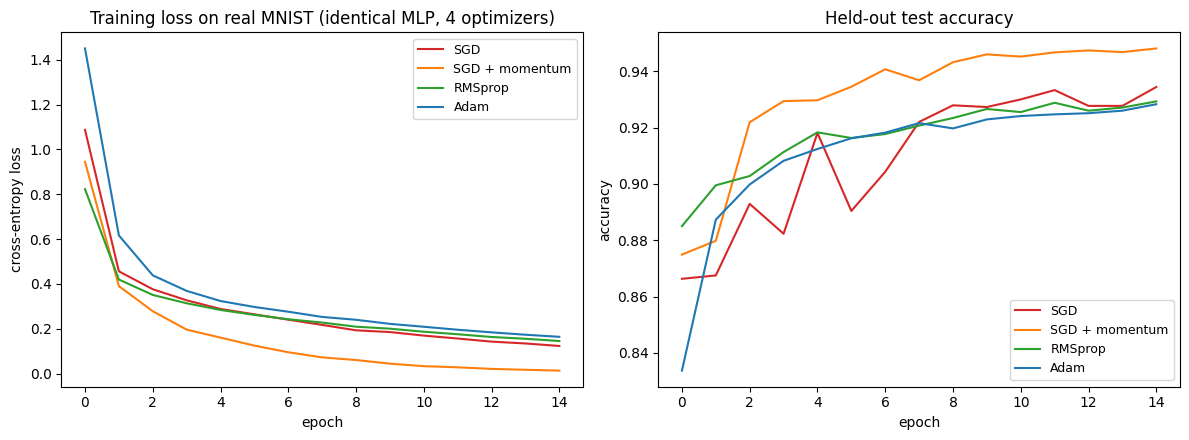

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name in optimizer_names:
    axes[0].plot(results[name]["train_losses"], label=name, color=colors[name])
    axes[1].plot(results[name]["test_accs"], label=name, color=colors[name])

axes[0].set_title("Training loss on real MNIST (identical MLP, 4 optimizers)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("cross-entropy loss")
axes[0].legend(fontsize=9)

axes[1].set_title("Held-out test accuracy")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


These numbers are real, from this run, not looked up from a paper —
and they are worth reading carefully, because the ranking is **not** the
"Adam always wins" story a lot of optimizer folklore would predict:

- **SGD + momentum** (`lr=0.1`, momentum `0.9`) is the clear winner here on
  *both* training loss and test accuracy — it drives training loss down to
  roughly a tenth of what the other three reach in the same 15 epochs, and
  finishes with the highest held-out test accuracy of the four.
- **Plain SGD** (fixed `lr=0.3`, no momentum) does reasonably despite having
  no memory mechanism at all, because its learning rate happens to be large
  enough for this small, well-behaved MLP.
- **RMSprop and Adam**, at their common default learning rate `0.001`, are
  the *slowest* of the four to bring down training loss on this problem in
  only 15 epochs. This isn't a bug in the implementation — `torch.optim`'s
  defaults are simply tuned to be safe across many problems, not optimal for
  this exact tiny MLP/small-dataset setup, and 15 epochs is not enough time
  for Adam's conservative default step size to catch up to a well-tuned
  momentum run.

**This is a real, reproducible instance of the debate covered in Limitations
& debates below**: a properly-configured SGD + momentum can out-perform
Adam/RMSprop's out-of-the-box defaults, both in convergence speed *and*
final test accuracy, on the same architecture and data. It does not mean
Adam is a bad optimizer — with a larger learning rate or more epochs, Adam
typically closes most of this gap — but it is a concrete demonstration of
why "just use Adam" is a reasonable *default*, not a universal law, and why
practitioners who care about squeezing out the last bit of accuracy still
tune and use SGD + momentum on some problems.


## A related practical technique: learning rate schedules

Even the best optimizer still needs *some* learning rate $\eta$, and a single
fixed $\eta$ for all of training is rarely optimal: a larger $\eta$ helps
early (fast initial progress, and some noise can help escape poor regions),
while a smaller $\eta$ helps late (fine-grained convergence near a minimum,
without overshooting it). A **learning rate schedule** shrinks $\eta$ over
the course of training according to a fixed rule. Two common ones:

- **Step decay**: multiply $\eta$ by a constant factor $\gamma < 1$ every
  $k$ epochs — a simple staircase.
- **Cosine annealing**: smoothly decay $\eta$ along a cosine curve from its
  initial value down to (near) zero over the course of training:
  $$
  \eta_t = \eta_{\min} + \tfrac{1}{2}(\eta_0 - \eta_{\min})\left(1 + \cos\!\left(\tfrac{t}{T}\pi\right)\right)
  $$
  for step $t$ out of $T$ total steps (Loshchilov & Hutter, 2017's SGDR).

We compare a fixed learning rate against a cosine schedule, using SGD +
momentum (the optimizer where the choice of $\eta$ tends to matter most in
practice) so the effect of the schedule isn't masked by an already-adaptive
per-parameter step size.


SGD+momentum, fixed lr=0.1:              final test accuracy = 94.81%
SGD+momentum, cosine-annealed from 0.1:   final test accuracy = 94.57%


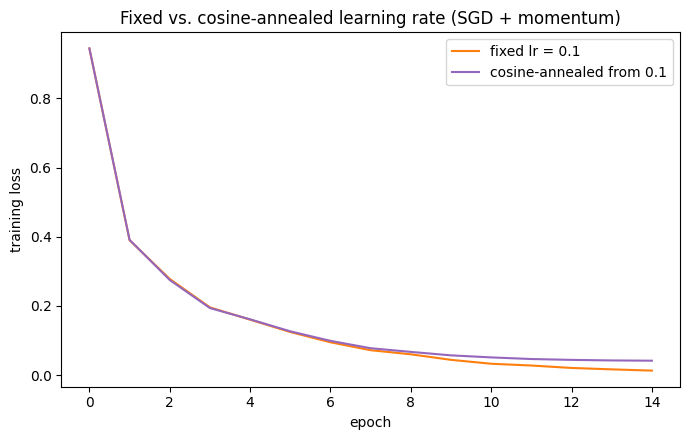

In [9]:
def cosine_scheduler(opt, n_epochs=15):
    return torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

fixed_losses, fixed_accs, fixed_final = train("SGD + momentum", n_epochs=15)
cos_losses, cos_accs, cos_final = train("SGD + momentum", n_epochs=15, lr_scheduler=cosine_scheduler)

print(f"SGD+momentum, fixed lr=0.1:              final test accuracy = {fixed_final*100:.2f}%")
print(f"SGD+momentum, cosine-annealed from 0.1:   final test accuracy = {cos_final*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(fixed_losses, label="fixed lr = 0.1", color="#ff7f0e")
ax.plot(cos_losses, label="cosine-annealed from 0.1", color="#9467bd")
ax.set_title("Fixed vs. cosine-annealed learning rate (SGD + momentum)")
ax.set_xlabel("epoch"); ax.set_ylabel("training loss")
ax.legend()
plt.tight_layout()
plt.show()


The cosine-annealed run keeps the same large early steps (fast initial
progress) but tapers $\eta$ toward zero in the final epochs, which typically
shows up as a *lower, less noisy* loss in the last few epochs than the fixed
schedule — the model is taking smaller, more careful steps exactly when it's
close to a minimum, instead of continuing to overshoot at a constant rate. In
practice, schedules and adaptive optimizers are not either/or: it is
completely standard to run Adam or SGD+momentum *with* a schedule on top —
the schedule and the optimizer solve related but distinct problems (how big
a step overall vs. how to shape/scale that step per parameter).


## Use cases

- **Adam / AdamW as the default.** For the large majority of modern deep
  learning — transformers, most computer vision research code, RL policy
  networks — Adam or its weight-decay-corrected variant **AdamW**
  (Loshchilov & Hutter, 2019) is the practitioner's default first choice,
  precisely because it is fast to converge and comparatively forgiving of an
  imperfectly-tuned learning rate. Virtually every large language model
  published in the last several years reports AdamW as its optimizer.
- **SGD + momentum in vision training recipes.** Many well-known, carefully
  tuned image classification recipes (e.g. training ResNets on ImageNet)
  still use plain SGD with momentum (and a schedule) rather than Adam,
  because — with enough tuning — it has been repeatedly observed to reach
  *better final test accuracy* on some vision benchmarks, even though it
  converges more slowly during training (see Limitations & debates below).
  It's slower to tune but can win once tuned.
- **RMSprop in recurrent/reinforcement-learning settings.** RMSprop (and
  Adam) were historically popular for RNNs and early deep RL (e.g. the
  original DQN paper) where gradients can vary wildly in scale across
  parameters and across time, making per-parameter adaptive scaling
  especially valuable.
- **Learning rate schedules essentially everywhere.** Whatever optimizer is
  chosen, pairing it with a schedule (step decay, cosine annealing, linear
  warmup followed by decay) is close to universal practice in production
  training runs, not an optional extra.


## Limitations & debates

- **Adaptive methods don't always generalize as well.** Wilson et al. (2017),
  *"The Marginal Value of Adaptive Gradient Methods in Machine Learning,"*
  showed empirically that on several standard vision benchmarks, models
  trained with adaptive methods (Adam, RMSprop, Adagrad) reached *lower
  training loss faster* than SGD + momentum, but generalized *worse* — a
  well-tuned SGD + momentum baseline reached better held-out test accuracy.
  This is not a universally settled question — later work (and AdamW's
  correction of Adam's weight decay implementation) narrowed the gap in many
  settings — but it is a genuinely open and actively debated area, not a
  solved one, and it is a documented reason practitioners still hand-tune
  plain SGD for some vision architectures.
- **"Well-tuned" is doing a lot of work.** Comparisons between optimizers are
  extremely sensitive to how much hyperparameter search each one gets.
  Adam's headline advantage is being *reasonably good with default
  hyperparameters*; SGD + momentum can often match or beat it, but typically
  needs a proper learning-rate (and schedule) search to do so. Casual,
  single-run comparisons (including the one in this tutorial) should be read
  as illustrating the *mechanism*, not as a rigorous benchmark of which
  optimizer is "best."
- **Adaptive methods are still sensitive to the learning rate**, just less so
  than plain SGD. "Adaptive" refers to the *per-parameter relative* scaling,
  not to the overall step size — Adam with a learning rate that's off by 10x
  in either direction can still diverge or stall, and $\eta$ is still the
  most important hyperparameter to tune first.
- **Adam's original bias-correction / convergence proof had a bug.** Reddi,
  Kale & Kumar (2018), *"On the Convergence of Adam and Beyond,"* showed
  Adam's original convergence proof was flawed and constructed simple convex
  counter-examples where Adam fails to converge; they proposed **AMSGrad** as
  a fix. In practice plain Adam (and AdamW) still work well on most deep
  learning problems, but "Adam always converges" is not a proven guarantee.
- **Extra memory cost.** Momentum, RMSprop, and Adam all require storing one
  or two extra tensors the same size as the model's parameters ($v_t$ for
  momentum; $s_t$ for RMSprop; $m_t$ **and** $v_t$ for Adam — i.e. Adam
  roughly *triples* the optimizer state memory versus plain SGD). This is a
  real, practical constraint at the scale of billion-parameter models, and
  is one motivation behind memory-efficient optimizer variants (e.g.
  Adafactor, 8-bit Adam).


## References

- Sutskever, I., Martens, J., Dahl, G., & Hinton, G. (2013). *On the
  importance of initialization and momentum in deep learning.* ICML.
- Tieleman, T. & Hinton, G. (2012). *Lecture 6.5 - RMSProp*, COURSERA: Neural
  Networks for Machine Learning (unpublished lecture notes; the origin of
  RMSprop).
- Kingma, D. P. & Ba, J. (2015). *Adam: A Method for Stochastic
  Optimization.* ICLR.
- Reddi, S. J., Kale, S., & Kumar, S. (2018). *On the Convergence of Adam and
  Beyond.* ICLR.
- Loshchilov, I. & Hutter, F. (2019). *Decoupled Weight Decay Regularization*
  (AdamW). ICLR.
- Loshchilov, I. & Hutter, F. (2017). *SGDR: Stochastic Gradient Descent with
  Warm Restarts* (cosine annealing schedules). ICLR.
- Wilson, A. C., Roelofs, R., Stern, M., Srebro, N., & Recht, B. (2017). *The
  Marginal Value of Adaptive Gradient Methods in Machine Learning.* NeurIPS.
- Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, MIT
  Press, Chapter 8 (Optimization for Training Deep Models).
- LeCun, Y., Cortes, C., & Burges, C. J. C. *The MNIST Database of
  Handwritten Digits.* [yann.lecun.com/exdb/mnist](http://yann.lecun.com/exdb/mnist/)
